# getting_contours_saved_in_spatialite.ipynb

I used this notebook to learn how to use contours saved as WKB blobs in SpatiaLite.

Here the steps I want to accomplish:

1. Open a test database containing images and tree contours extracted using the SAM3 segmentation model.
2. Visually check that the that the tree contour fits the tree image
3. EFD reconstruction

## The next 3 cells show how to prevent interactions between plots when using the ipympl backend

[Reference](https://www.google.com/search?client=ubuntu-sn&channel=fs&q=prevent+interaction+between+pyplots+&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832SMIiTl3t-JZ4hGJOxPbHYSIu8Q64jU5EwQ-803VaKbdipNP9IdSJPNW0dZW-vtpfTgsxPubDUGnnlexyWPgXsYNlXlmyPinvUYfER67uhQ5Vfbik35T4Dg9gniUKXVW_UbnTVWpRess5NuzktlkeG__xvaIML5bSATkoDeT0MVLmDH1TQ&aep=10&ntc=1&sxsrf=APpeQnuCd_6MVXzzQxdSzWz_3X_slxLXZw%3A1786782435532&mstk=AUtExfCN6_3MDnlnjACT336tKmJmpfYkB4yE5VkAlGzRlOUwnO8Y7K1makAXMAFMvoyyIyVipf-QBT8kuKkDOo9vjuj_93BRl4DQym8gA1i-d1YBBncJw2blmnbSgqWAaPOAUZp-cgRJ-ZmwGDrZQTieTjC8nfZf70Hp5hMge9r4R2KmtA19JVPQ1Dl7gx9MXxWgQTmN1p-5zAsGGSZtk_u-cQergf_F71GV_g_BVmsoSkC8BWcQAfoPTQ1b0cAICV_T161tHSCI3CFYvQ&aioh=3&csuir=1&atvm=2&mtid=CiiAao3TLOXk2roPgs3IaQ)

Convert the cells from raw to Python to execute them.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import sqlite3
from icecream import ic
from shapely import wkb, to_wkt
from shapely.geometry import Polygon
import numpy as np
import cv2
import matplotlib.pyplot as plt
import efd_find_cuts as efd

# 1 Open a test database

In [2]:
db_path = 'test.db'
image_id = 1
tree_id = 1
order = 20

In [3]:
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

# 2. Visually check that the that the tree contour fits the tree image

ic| tree_contour: array([[486, 677],
                         [486, 682],
                         [485, 683],
                         ...,
                         [488, 678],
                         [487, 678],
                         [486, 677]], shape=(1084, 2), dtype=int32)
ic| tree_contour.dtype: dtype('int32')
ic| type(tree_contour): <class 'numpy.ndarray'>


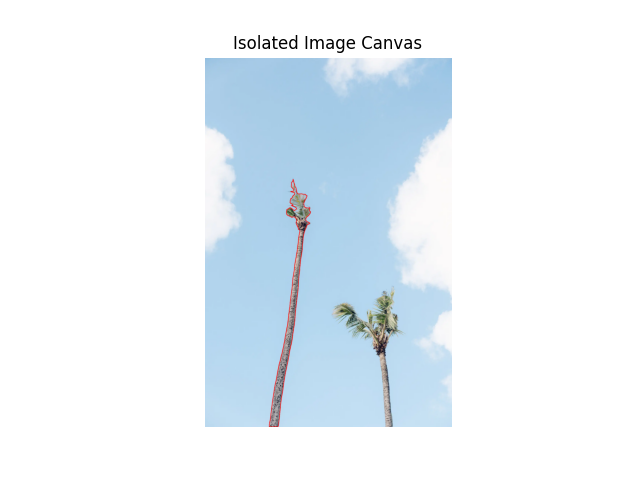

In [20]:
sql = 'SELECT image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1'
image_path = cursor.execute(sql).fetchone()[0]

sql = 'SELECT AsBinary(tree_poly) FROM trees WHERE tree_id=1'
tree_poly_binary = cursor.execute(sql).fetchone()[0]
# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
tree_poly_str = wkb.loads(tree_poly_binary)
tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
ic(tree_contour)
ic(tree_contour.dtype)
ic(type(tree_contour))
len(tree_contour)



# 1. Load your image file into an array
# img = mpimg.imread(image_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.polylines(img, [tree_contour], color=(255,0,0), isClosed=True, thickness=2)



# 2. Setup isolated figure handle
fig, ax = plt.subplots()

# 3. Render image data on specific axis handle
ax.imshow(img)
ax.set_title("Isolated Image Canvas")

# 4. Clean window frame properties (Optional)
ax.axis('off') 

plt.show()

## Get the contour of the first tree

This is the contour calculated by SAM3 which is saved as a blob in the `tree_poly` field of the `v_tree_poly` view.

In [ ]:
# cursor.execute('SELECT * FROM v_tree_poly')
cursor.execute(f"SELECT image_width, image_height, AsBinary(tree_poly) AS tree_poly_binary FROM v_tree_poly WHERE tree_id = {tree_id}")
image_width, image_height, tree_poly_binary = cursor.fetchone()

# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
tree_poly_str = wkb.loads(tree_poly_binary)
tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
ic(tree_contour)
ic(tree_contour.dtype)
ic(type(tree_contour))
len(tree_contour)

# Visualize the tree contour.

In [ ]:
img = mpimg.imread('data_cache/example_images/08hs-palms-03-zglw-superJumbo.webp')








# fig, ax = plt.subplots()
# tree_mask = np.zeros((image_width, image_height, 1), dtype=np.uint8)
# cv2.fillPoly(tree_mask, [tree_contour], 255)
# plt.imshow(tree_mask);

# Make sure the contour surrounds the detected tree

In [ ]:
cursor.execute('SELECT tree_id, image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1')
_, image_path = cursor.fetchone()
img = cv2.imread(image_path)
cv2.polylines(img, [tree_contour], color=(0,0,255), isClosed=True, thickness=2)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1,1)
plt.imshow(img);

In [ ]:
results = efd.efd_find_cuts(
    original_contour=tree_contour, 
    original_mask=tree_mask,
    order=order
    )
my_fig, my_axs = efd.plot_efd_results(results)
plt.show()

In [ ]:
img = results.original_mask
cv2.fillPoly(img, results.vcut_contours, 128)
plt.imshow(img[600:1000, 250:750]);


In [ ]:
for contour in results.vcut_contours:
    # convert countour to WKT format using Shapely
    squeeze_contour = np.squeeze(contour)  # Shape becomes (N, 2)
    poly = Polygon(squeeze_contour)
    wkt_string = to_wkt(poly)
    
    conn.execute(
        'INSERT INTO damage (image_id, tree_id, damage_poly) VALUES (?, ?, GeomFromText(?, 0))', 
        (image_id, tree_id, wkt_string)
    )
    
conn.commit()

# Visually check alignment of efd reconstructed poly and tree-poly

|color|var|
|--|--|
|white:|tree_contour|
|red:|aligned_recon|
|green:|raw_recon|

# !! Something weird here: "aligned_recon is misaligned" !!

# 3. EFD reconstruction

In [25]:
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour

img_height, img_width, _ = img.shape

original_contour=tree_contour
ic(tree_contour)

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)

ic(original_contour.astype(np.int32));

img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)
plt.imshow(img[600:1000, 250:750]);

ic| tree_contour: array([[486, 677],
                         [486, 682],
                         [485, 683],
                         ...,
                         [488, 678],
                         [487, 678],
                         [486, 677]], shape=(1084, 2), dtype=int32)
ic| original_contour: array([[486., 677.],
                             [486., 682.],
                             [485., 683.],
                             ...,
                             [488., 678.],
                             [487., 678.],
                             [486., 677.]], shape=(1084, 2))
ic| original_contour.astype(np.int32): array([[486, 677],
                                              [486, 682],
                                              [485, 683],
                                              ...,
                                              [488, 678],
                                              [487, 678],
                                              [486, 677]], shape=(

# Now calculate mask containing pixels which are in the reconstruction mask but not in the original mask

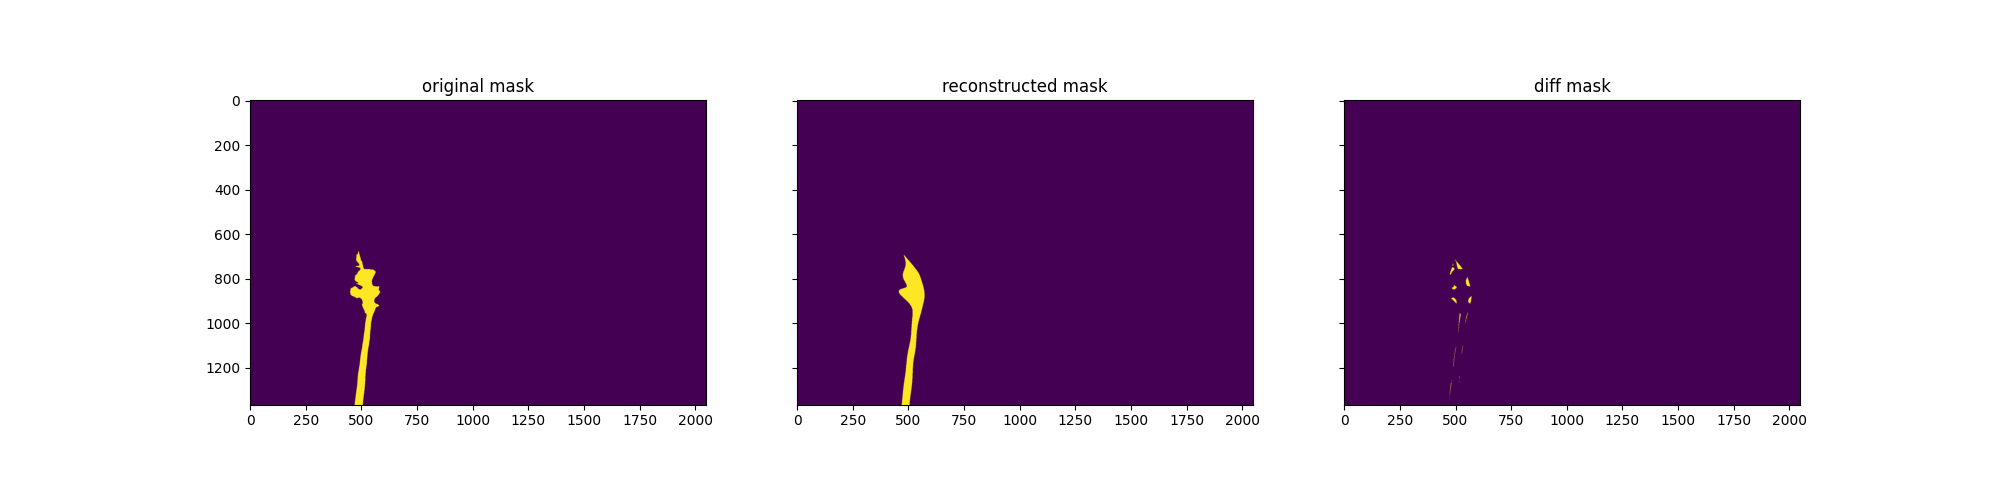

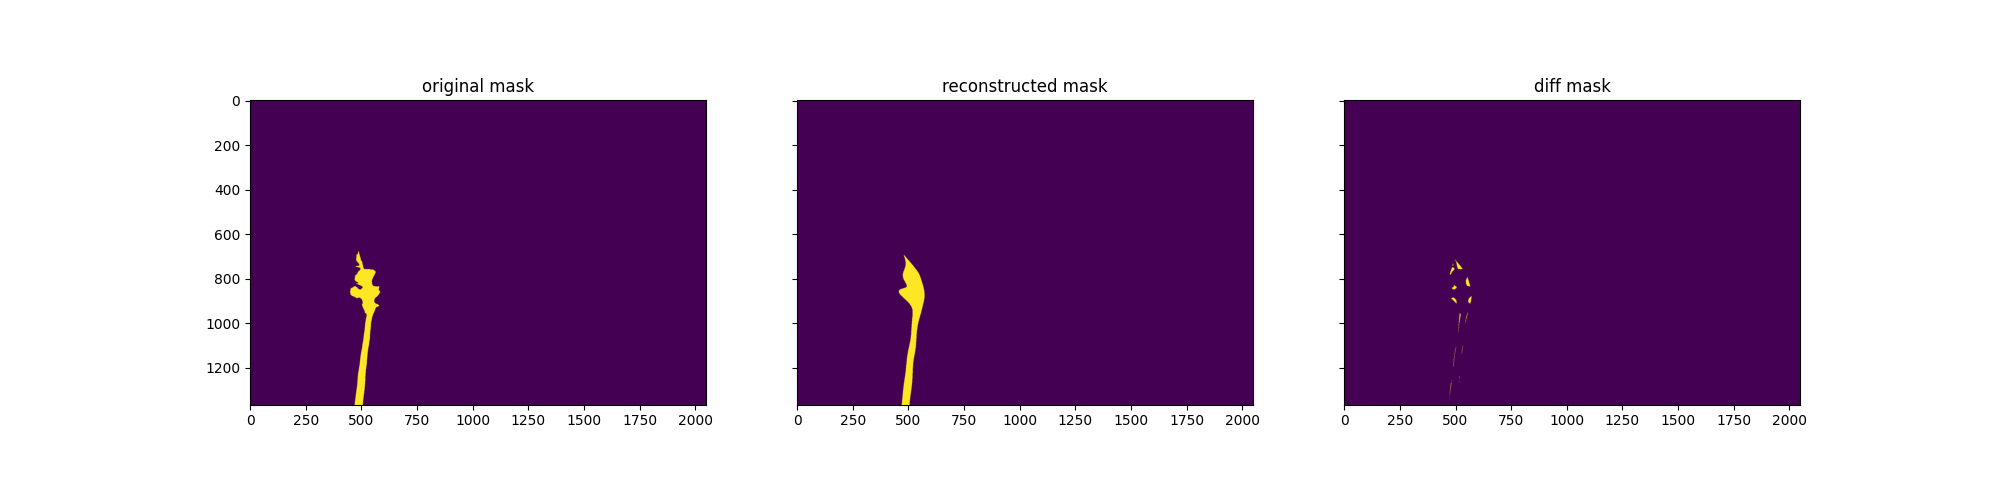

In [26]:
original_mask = np.zeros((img_width, img_height), dtype=np.uint8)
reconstructed_mask = np.zeros((img_width, img_height), dtype=np.uint8)

cv2.fillPoly(original_mask, pts=[original_contour.astype(np.int32)], color=255)
cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(np.int32)], color=255)

# Pixels missing in original, present in reconstruction
diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
axs[0].imshow(original_mask)
axs[0].set_title('original mask')
axs[1].imshow(reconstructed_mask)
axs[1].set_title('reconstructed mask')
axs[2].imshow(diff_mask)
axs[2].set_title('diff mask')
fig.show()


In [ ]:
efd_results = efd.efd_find_cuts(
    original_contour=tree_contour,
    original_mask=tree_mask,
    order=order)
efd.plot_efd_results(efd_results);

In [ ]:
conn.close()
ic('Finished')